Engine Specifications:
Bore: 93 mm
Stroke: 92 mm
Conrod length: 156 mm
Clearance volume: 36.8 cm³
Displacement volume: 624.9 cm³
Compression ratio: 18.0:1


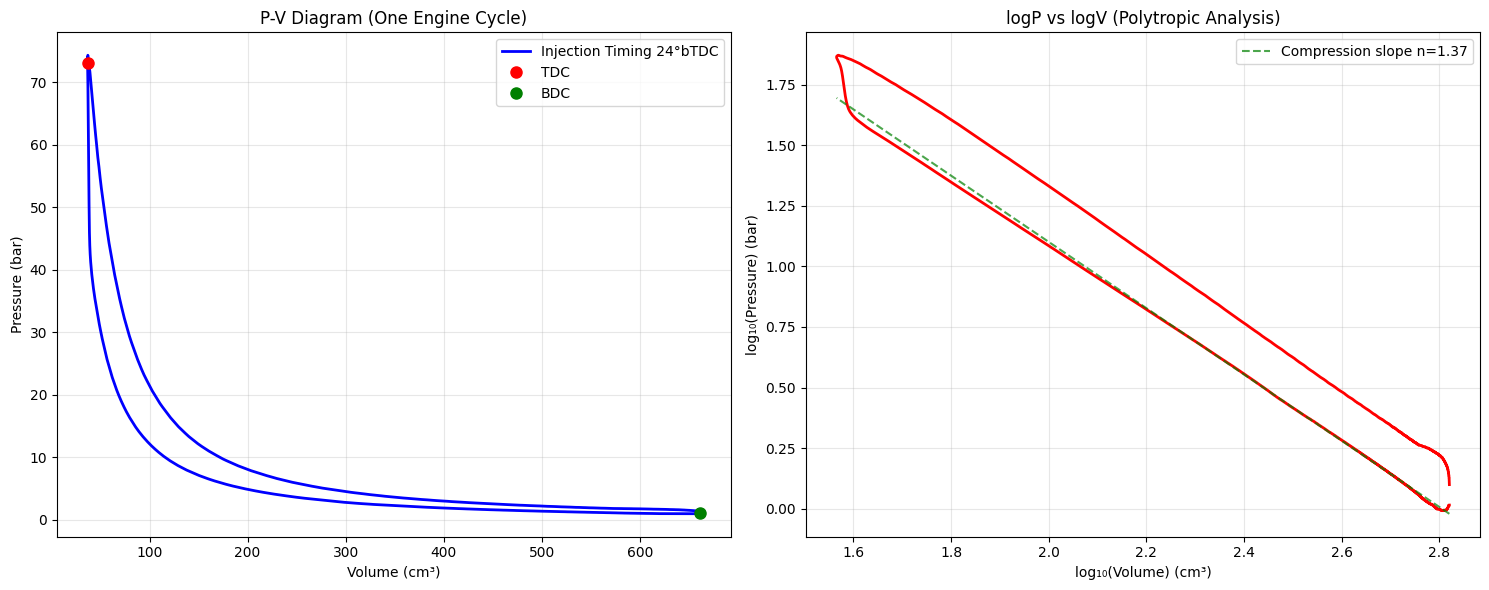


=== ENGINE CYCLE ANALYSIS ===
Cycle range: -180.0° to 180.0°
Volume range: 36.76 - 661.71 cm³
Peak pressure: 74.29 bar @ +2.2°
TDC pressure: 73.10 bar
BDC pressure: 1.04 bar
Approximate net work: 221.08 J/cycle
Polytropic constant (compression): 1.37


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ===============================================
# ENGINE GEOMETRY PARAMETERS (TYPICAL VALUES)
# ===============================================
bore = 0.093          # Bore diameter: 93 mm (typical single-cylinder diesel)
stroke = 0.092        # Stroke length: 92 mm
crank_radius = stroke / 2  # = 0.043 m (r)
conrod_length = 0.156     # Connecting rod length: 156 mm
v_swept = np.pi*(bore/2)**2*stroke;
rc = 18; # comp ratio is 18
## Vs+Vc/vc =18 -> Vs/vc = 17;
clearance_volume = v_swept/(rc-1); # Clearance volume: 12 cm³ (CR ≈ 16:1 typical diesel)

# Derived parameters
piston_area = np.pi * (bore/2)**2  # m²
disp_volume = piston_area * stroke # m³ (displacement volume)

print("Engine Specifications:")
print(f"Bore: {bore*1000:.0f} mm")
print(f"Stroke: {stroke*1000:.0f} mm")
print(f"Conrod length: {conrod_length*1000:.0f} mm")
print(f"Clearance volume: {clearance_volume*1e6:.1f} cm³")
print(f"Displacement volume: {disp_volume*1e6:.1f} cm³")
print(f"Compression ratio: {rc:.1f}:1")

# ===============================================
# READ AND PROCESS DATA
# ===============================================
data = pd.read_csv('Injection_Timing_24bTDC.txt', sep='\t|\r', engine='python',
                   names=['crank_angle', 'pressure_bar'], skiprows=2)

# Convert columns to numeric, coercing errors
data['crank_angle'] = pd.to_numeric(data['crank_angle'], errors='coerce')
data['pressure_bar'] = pd.to_numeric(data['pressure_bar'], errors='coerce')

data = data.dropna().reset_index(drop=True)

# Focus on one complete cycle (-180° to 180° around TDC)
mask = (data['crank_angle'] >= -180) & (data['crank_angle'] <= 180)
cycle_data = data.loc[mask].reset_index(drop=True)

theta_deg = cycle_data['crank_angle'].values
theta_rad = np.radians(theta_deg)
P_bar = cycle_data['pressure_bar'].values

# ===============================================
# CYLINDER VOLUME CALCULATION
# ===============================================
def cylinder_volume(theta_rad, r=crank_radius, l=conrod_length,
                   Vc=clearance_volume, A=piston_area):
    """
    Calculate instantaneous cylinder volume from crank angle
    V(θ) = Vc + A * [r(1-cosθ) + l - sqrt(l² - (r*sinθ)²)]
    """
    s = r * (1 - np.cos(theta_rad)) + l - np.sqrt(l**2 - (r * np.sin(theta_rad))**2)
    V = Vc + A * s  # in m³
    return V * 1e6  # Convert to cm³ for plotting

# Calculate volumes
V_cm3 = cylinder_volume(theta_rad)

# ===============================================
# CREATE P-V AND logP-logV PLOTS
# ===============================================
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# P-V Diagram
ax1.plot(V_cm3, P_bar, 'b-', linewidth=2, label='Injection Timing 24°bTDC')
ax1.set_xlabel('Volume (cm³)')
ax1.set_ylabel('Pressure (bar)')
ax1.set_title('P-V Diagram (One Engine Cycle)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Mark key points
tdc_idx = np.argmin(V_cm3)
bdc_idx = np.argmax(V_cm3)
ax1.plot(V_cm3[tdc_idx], P_bar[tdc_idx], 'ro', markersize=8, label='TDC')
ax1.plot(V_cm3[bdc_idx], P_bar[bdc_idx], 'go', markersize=8, label='BDC')
ax1.legend()

# logP vs logV (for polytropic analysis)
mask_log = (P_bar > 0.1) & (V_cm3 > 0)  # Avoid log(0)
logV = np.log10(V_cm3[mask_log])
logP = np.log10(P_bar[mask_log])

ax2.plot(logV, logP, 'r-', linewidth=2)
ax2.set_xlabel('log₁₀(Volume) (cm³)')
ax2.set_ylabel('log₁₀(Pressure) (bar)')
ax2.set_title('logP vs logV (Polytropic Analysis)')
ax2.grid(True, alpha=0.3)

# Add polytropic slope reference lines
# Define compression range using the indices from BDC to TDC
# bdc_idx is 0 (for -180 degrees)
# tdc_idx is ~1800 (for 0 degrees)
compression_indices_for_fit = np.arange(bdc_idx, tdc_idx + 1) # +1 to include tdc_idx

polytropic_constant = None
if len(compression_indices_for_fit) > 10:
    # Filter logV and logP using the selected indices for compression
    logV_compression_fit = logV[compression_indices_for_fit]
    logP_compression_fit = logP[compression_indices_for_fit]

    p = np.polyfit(logV_compression_fit, logP_compression_fit, 1)
    polytropic_constant = -p[0] # Take the negative of the slope to get n
    ax2.plot(logV_compression_fit, p[0]*logV_compression_fit + p[1], 'g--', alpha=0.7,
             label=f'Compression slope n={polytropic_constant:.2f}')
    ax2.legend()

plt.tight_layout()
plt.savefig('PV_logP_logV_24bTDC.png', dpi=300, bbox_inches='tight')
plt.show()

# ===============================================
# ANALYSIS RESULTS
# ===============================================
print("\n=== ENGINE CYCLE ANALYSIS ===")
print(f"Cycle range: {theta_deg[0]:.1f}° to {theta_deg[-1]:.1f}°")
print(f"Volume range: {V_cm3.min():.2f} - {V_cm3.max():.2f} cm³")
print(f"Peak pressure: {P_bar.max():.2f} bar @ {theta_deg[np.argmax(P_bar)]:+.1f}°")
print(f"TDC pressure: {P_bar[tdc_idx]:.2f} bar")
print(f"BDC pressure: {P_bar[bdc_idx]:.2f} bar")

# Calculate indicated work (approximate) - Corrected calculation for area enclosed by P-V diagram
# The integral of P dV is sum(P * dV)
# We convert P from bar to Pa (1 bar = 1e5 Pa) and V from cm³ to m³ (1 cm³ = 1e-6 m³)
net_work = np.sum(P_bar[:-1] * np.diff(V_cm3)) * 1e5 * 1e-6  # J
print(f"Approximate net work: {net_work:.2f} J/cycle")
if polytropic_constant is not None:
    print(f"Polytropic constant (compression): {polytropic_constant:.2f}")

### Heat Release Rate Calculation

The heat release rate ($
rac{dQ}{d\theta}$) is calculated using the first law of thermodynamics for a closed system, often expressed as:

$\frac{dQ}{d\theta} = \frac{\gamma}{\gamma - 1} P \frac{dV}{d\theta} + \frac{1}{\gamma - 1} V \frac{dP}{d\theta}$

Where:
*   $P$ is the cylinder pressure.
*   $V$ is the cylinder volume.
*   $\theta$ is the crank angle.
*   $\gamma$ is the ratio of specific heats (adiabatic index).

For this calculation, we will assume a typical value for $\gamma$ of 1.35. This value can vary depending on the temperature and composition of the cylinder gases.

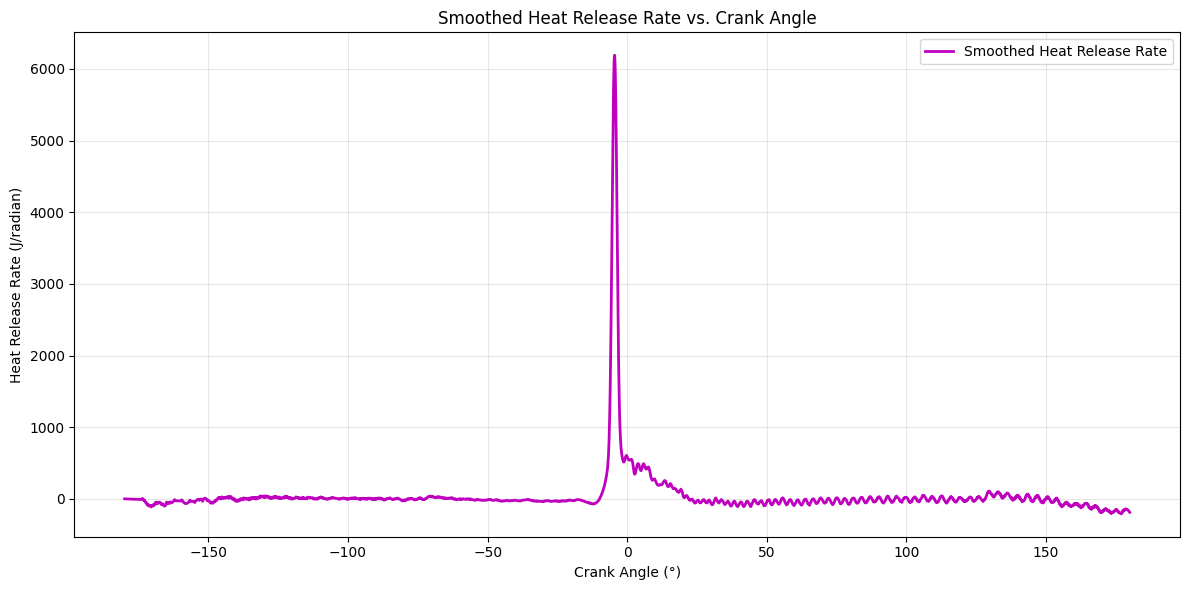

Assumed gamma (ratio of specific heats): 1.35
Savitzky-Golay filter applied with window_length=31 and poly_order=3


In [11]:
# ===============================================
# HEAT RELEASE RATE CALCULATION
# ===============================================

from scipy.signal import savgol_filter

# Define the ratio of specific heats (gamma)
gamma = 1.35 # Typical value for combustion products in diesel engines

# Convert pressure from bar to Pascals (1 bar = 1e5 Pa)
P_Pa = P_bar * 1e5

# Convert volume from cm³ to m³ (1 cm³ = 1e-6 m³)
V_m3 = V_cm3 * 1e-6

# --- Apply Savitzky-Golay filter to smooth P and V data ---
# Window length should be odd and smaller than the total number of data points
# polyorder is the order of the polynomial used to fit the samples
window_length = 31 # This value can be adjusted for desired smoothing
poly_order = 3     # This value can be adjusted

# Ensure window_length is less than the data length
if window_length >= len(P_Pa):
    window_length = len(P_Pa) - 1 if len(P_Pa) % 2 == 0 else len(P_Pa)
    if window_length < 3: # Ensure minimum window length for Savitzky-Golay
        window_length = 3

P_Pa_smoothed = savgol_filter(P_Pa, window_length, poly_order)
V_m3_smoothed = savgol_filter(V_m3, window_length, poly_order)

# Calculate derivatives dV/dtheta and dP/dtheta with respect to crank angle in radians
# np.gradient calculates the derivative using central differences
dV_dtheta_smoothed = np.gradient(V_m3_smoothed, theta_rad)
dP_dtheta_smoothed = np.gradient(P_Pa_smoothed, theta_rad)

# Calculate Heat Release Rate (dQ/dtheta)
# dQ/dtheta = [gamma/(gamma-1)] * P * (dV/dtheta) + [1/(gamma-1)] * V * (dP/dtheta)
dQ_dtheta_smoothed = (gamma / (gamma - 1)) * P_Pa_smoothed * dV_dtheta_smoothed + \
                     (1 / (gamma - 1)) * V_m3_smoothed * dP_dtheta_smoothed

# ===============================================
# CREATE SMOOTHED HEAT RELEASE RATE PLOT
# ===============================================
plt.figure(figsize=(12, 6))
plt.plot(theta_deg, dQ_dtheta_smoothed, 'm-', linewidth=2, label='Smoothed Heat Release Rate')
plt.xlabel('Crank Angle (°)')
plt.ylabel('Heat Release Rate (J/radian)')
plt.title('Smoothed Heat Release Rate vs. Crank Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Smoothed_HeatReleaseRate_CrankAngle_24bTDC.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Assumed gamma (ratio of specific heats): {gamma}")
print(f"Savitzky-Golay filter applied with window_length={window_length} and poly_order={poly_order}")

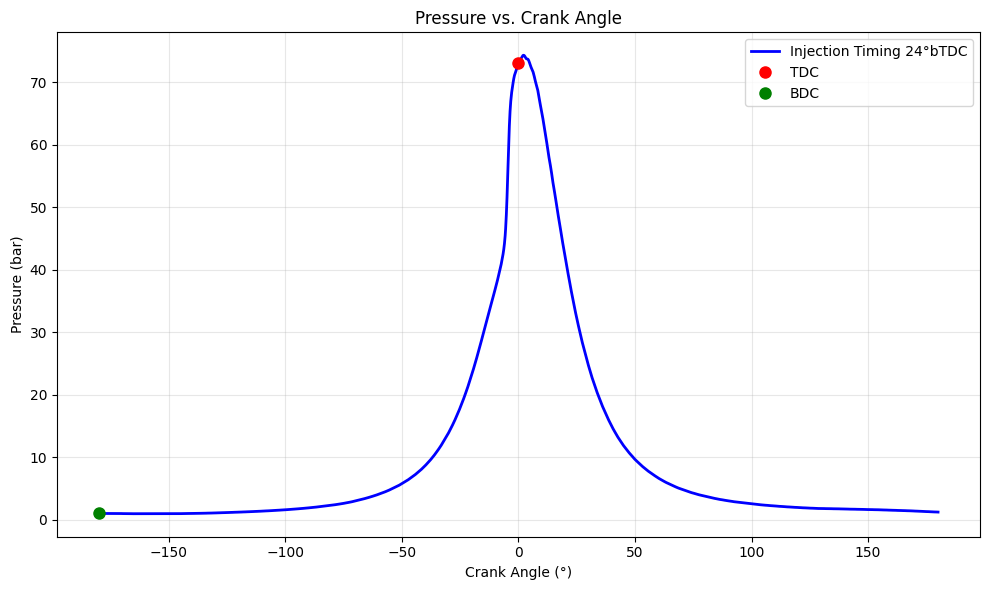

In [9]:
import matplotlib.pyplot as plt

# Create Pressure vs. Crank Angle plot
plt.figure(figsize=(10, 6))
plt.plot(theta_deg, P_bar, 'b-', linewidth=2, label='Injection Timing 24°bTDC')
plt.xlabel('Crank Angle (°)')
plt.ylabel('Pressure (bar)')
plt.title('Pressure vs. Crank Angle')
plt.grid(True, alpha=0.3)
plt.legend()

# Mark key points
tdc_idx = np.argmin(V_cm3)
bdc_idx = np.argmax(V_cm3)
plt.plot(theta_deg[tdc_idx], P_bar[tdc_idx], 'ro', markersize=8, label='TDC')
plt.plot(theta_deg[bdc_idx], P_bar[bdc_idx], 'go', markersize=8, label='BDC')
plt.legend()
plt.tight_layout()
plt.savefig('Pressure_CrankAngle_24bTDC.png', dpi=300, bbox_inches='tight')
plt.show()

You can upload files in Google Colab using one of these methods:

1.  **Using the file browser:**
    *   On the left sidebar, click the folder icon to open the 'Files' tab.
    *   Click the 'Upload to session storage' icon (it looks like a page with an arrow pointing up).
    *   Select the file(s) from your local computer.
    *   *Note: Files uploaded this way will be deleted when the runtime disconnects.*

2.  **Using `files.upload()` in Python:**
    *   Run the following Python code in a cell. A button will appear allowing you to select files from your local system.


In [ ]:
from google.colab import files

uploaded = files.upload()

3.  **Mounting Google Drive:**
    *   You can mount your Google Drive to access files directly from there. This is persistent across sessions.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful